# Assignment 2

In this assigment, we will work with the *Forest Fire* data set. Please download the data from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/162/forest+fires). Extract the data files into the subdirectory: `../data/fires/` (relative to `./05_src/`).

## Objective

+ The model objective is to predict the area affected by forest fires given the features set. 
+ The objective of this exercise is to assess your ability to construct and evaluate model pipelines.
+ Please note: the instructions are not meant to be 100% prescriptive, but instead they are a set of minimum requirements. If you find predictive performance gains by applying additional steps, by all means show them. 

## Variable Description

From the description file contained in the archive (`forestfires.names`), we obtain the following variable descriptions:

1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
3. month - month of the year: "jan" to "dec" 
4. day - day of the week: "mon" to "sun"
5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
6. DMC - DMC index from the FWI system: 1.1 to 291.3 
7. DC - DC index from the FWI system: 7.9 to 860.6 
8. ISI - ISI index from the FWI system: 0.0 to 56.10
9. temp - temperature in Celsius degrees: 2.2 to 33.30
10. RH - relative humidity in %: 15.0 to 100
11. wind - wind speed in km/h: 0.40 to 9.40 
12. rain - outside rain in mm/m2 : 0.0 to 6.4 
13. area - the burned area of the forest (in ha): 0.00 to 1090.84 









### Specific Tasks

+ Construct four model pipelines, out of combinations of the following components:

    + Preprocessors:

        - A simple processor that only scales numeric variables and recodes categorical variables.
        - A transformation preprocessor that scales numeric variables and applies a non-linear transformation.
    
    + Regressor:

        - A baseline regressor, which could be a [K-nearest neighbours model]() or a linear model like [Lasso](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html) or [Ridge Regressors](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ridge_regression.html).
        - An advanced regressor of your choice (e.g., Bagging, Boosting, SVR, etc.). TIP: select a tree-based method such that it does not take too long to run SHAP further below. 

+ Evaluate tune and evaluate each of the four model pipelines. 

    - Select a [performance metric](https://scikit-learn.org/stable/modules/linear_model.html) out of the following options: explained variance, max error, root mean squared error (RMSE), mean absolute error (MAE), r-squared.
    - *TIPS*: 
    
        * Out of the suggested metrics above, [some are correlation metrics, but this is a prediction problem](https://www.tmwr.org/performance#performance). Choose wisely (and don't choose the incorrect options.) 

+ Select the best-performing model and explain its predictions.

    - Provide local explanations.
    - Obtain global explanations and recommend a variable selection strategy.

+ Export your model as a pickle file.


You can work on the Jupyter notebook, as this experiment is fairly short (no need to use sacred). 

# Load the data

Place the files in the ../../05_src/data/fires/ directory and load the appropriate file. 

In [1]:
# Load the libraries as required.
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error
import pickle

In [2]:
# Load data
columns = [
    'coord_x', 'coord_y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh', 'wind', 'rain', 'area' 
]
fires_dt = (pd.read_csv('../../05_src/data/fires/forestfires.csv', header = 0, names = columns))
fires_dt.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   coord_x  517 non-null    int64  
 1   coord_y  517 non-null    int64  
 2   month    517 non-null    object 
 3   day      517 non-null    object 
 4   ffmc     517 non-null    float64
 5   dmc      517 non-null    float64
 6   dc       517 non-null    float64
 7   isi      517 non-null    float64
 8   temp     517 non-null    float64
 9   rh       517 non-null    int64  
 10  wind     517 non-null    float64
 11  rain     517 non-null    float64
 12  area     517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


In [3]:
fires_dt.head()

,coord_x,coord_y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


# Get X and Y

Create the features data frame and target data.

In [4]:
X = fires_dt.drop(columns='area')
y = fires_dt['area']

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Preprocessing

Create two [Column Transformers](https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html), called preproc1 and preproc2, with the following guidelines:

- Numerical variables

    * (Preproc 1 and 2) Scaling: use a scaling method of your choice (Standard, Robust, Min-Max). 
    * Preproc 2 only: 
        
        + Choose a transformation for any of your input variables (or several of them). Evaluate if this transformation is convenient.
        + The choice of scaler is up to you.

- Categorical variables: 
    
    * (Preproc 1 and 2) Apply [one-hot encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) where appropriate.


+ The only difference between preproc1 and preproc2 is the non-linear transformation of the numerical variables.
    


### Preproc 1

Create preproc1 below.

+ Numeric: scaled variables, no other transforms.
+ Categorical: one-hot encoding.

In [6]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

X_num = X[numeric_features]
X_cat = X[categorical_features]

transformer1 = ColumnTransformer(
    transformers=[
        ('num_transform', StandardScaler(), X_num.columns.values),
        ('cat_transform', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary'), X_cat.columns.values),
    ],
    remainder='drop'
)

### Preproc 2

Create preproc1 below.

+ Numeric: scaled variables, non-linear transformation to one or more variables.
+ Categorical: one-hot encoding.

In [7]:
numeric_transformer2 = Pipeline([
    ('Poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])
transformer2 = ColumnTransformer(
    transformers=[       
        ('num_transform', numeric_transformer2, X_num.columns.values ),
        ('cat_transform', OneHotEncoder(handle_unknown='infrequent_if_exist', drop='if_binary'), X_cat.columns.values), 
    ], remainder='drop'
)

## Model Pipeline


Create a [model pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html): 

+ Add a step labelled `preprocessing` and assign the Column Transformer from the previous section.
+ Add a step labelled `regressor` and assign a regression model to it. 

## Regressor

+ Use a regression model to perform a prediction. 

    - Choose a baseline regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Choose a more advance regressor, tune it (if necessary) using grid search, and evaluate it using cross-validation.
    - Both model choices are up to you, feel free to experiment.

In [8]:
# Pipeline A = preproc1 + baseline

pipeA = Pipeline(
    [
        ('preproc1', transformer1), 
        ('Ridge', Ridge())
    ]
)
pipeA

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc1', ...), ('Ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different

In [9]:
# Pipeline B = preproc2 + baseline
pipeB = Pipeline(
    [
        ('preproc2', transformer2), 
        ('Knn', KNeighborsRegressor())
    ]
)
pipeB

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc2', ...), ('Knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different t

In [10]:
# Pipeline C = preproc1 + advanced model
pipeC = Pipeline(
    [
        ('preproc1', transformer1), 
        ('RF_Regressor', RandomForestRegressor(n_jobs=-1, random_state=42))
    ]
)
pipeC

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc1', ...), ('RF_Regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the di

In [11]:
# Pipeline D = preproc2 + advanced model
pipeD = Pipeline(
    [
        ('preproc2', transformer2), 
        ('HistGradient_BR', HistGradientBoostingRegressor(random_state=42))
    ]
)
pipeD
    

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc2', ...), ('HistGradient_BR', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_transform', ...), ('cat_transform', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the

# Tune Hyperparams

+ Perform GridSearch on each of the four pipelines. 
+ Tune at least one hyperparameter per pipeline.
+ Experiment with at least four value combinations per pipeline.

In [12]:
param_grid_ridge = {
    'Ridge__alpha': [0.1, 1.0, 10.0],
    'Ridge__solver': ['auto', 'svd', 'cholesky', 'lsqr']
}
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']
grid_cv1 = GridSearchCV(
    estimator=pipeA,
    param_grid=param_grid_ridge,
    scoring=scoring,
    cv=5,
    refit='neg_root_mean_squared_error'
)
grid_cv1.fit(X_train, Y_train)

results_df = pd.DataFrame(grid_cv1.cv_results_)
results_df[['params', 'mean_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error']].sort_values('mean_test_neg_root_mean_squared_error', ascending=False)


/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklear

,params,mean_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error
8,"{'Ridge__alpha': 10.0, 'Ridge__solver': 'auto'}",-40.674197,-17.723577
10,"{'Ridge__alpha': 10.0, 'Ridge__solver': 'chole...",-40.674197,-17.723577
9,"{'Ridge__alpha': 10.0, 'Ridge__solver': 'svd'}",-40.674197,-17.723577
11,"{'Ridge__alpha': 10.0, 'Ridge__solver': 'lsqr'}",-40.677410,-17.725312
5,"{'Ridge__alpha': 1.0, 'Ridge__solver': 'svd'}",-41.090213,-18.212037
6,"{'Ridge__alpha': 1.0, 'Ridge__solver': 'choles...",-41.090213,-18.212037
4,"{'Ridge__alpha': 1.0, 'Ridge__solver': 'auto'}",-41.090213,-18.212037
7,"{'Ridge__alpha': 1.0, 'Ridge__solver': 'lsqr'}",-41.090883,-18.212846
1,"{'Ridge__alpha': 0.1, 'Ridge__solver': 'svd'}",-41.162784,-18.437814
0,"{'Ridge__alpha': 0.1, 'Ridge__solver': 'auto'}",-41.162784,-18.437814


In [13]:
param_grid_k_neighbors = {
    'Knn__n_neighbors': [3, 5, 6],
    'Knn__weights': ['uniform', 'distance']
}
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']
grid_cv2 = GridSearchCV(
    estimator=pipeB,
    param_grid=param_grid_k_neighbors,
    scoring=scoring,
    cv=5,
    refit='neg_root_mean_squared_error'
)
grid_cv2.fit(X_train, Y_train)
results_df = pd.DataFrame(grid_cv2.cv_results_)
results_df[['params', 'mean_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error']].sort_values('mean_test_neg_root_mean_squared_error', ascending=False)

/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklear

,params,mean_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error
4,"{'Knn__n_neighbors': 6, 'Knn__weights': 'unifo...",-42.082991,-16.137505
5,"{'Knn__n_neighbors': 6, 'Knn__weights': 'dista...",-42.998125,-16.206291
2,"{'Knn__n_neighbors': 5, 'Knn__weights': 'unifo...",-43.862868,-16.469375
3,"{'Knn__n_neighbors': 5, 'Knn__weights': 'dista...",-44.947760,-16.562653
0,"{'Knn__n_neighbors': 3, 'Knn__weights': 'unifo...",-51.529345,-18.623094
1,"{'Knn__n_neighbors': 3, 'Knn__weights': 'dista...",-52.248438,-18.582852


In [14]:
param_grid_rf = {
    "RF_Regressor__n_estimators": [100, 300, 500],
    "RF_Regressor__max_depth": [5, 10],
    "RF_Regressor__min_samples_split": [2, 5],
    "RF_Regressor__min_samples_leaf": [1, 2],
}
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']
grid_cv3 = GridSearchCV(
    estimator=pipeC,
    param_grid=param_grid_rf,
    scoring=scoring,
    cv=5,
    refit='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_cv3.fit(X_train, Y_train)
results_df = pd.DataFrame(grid_cv3.cv_results_)
results_df[['params', 'mean_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error']].sort_values('mean_test_neg_root_mean_squared_error', ascending=False)

/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklear

,params,mean_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error
11,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.658402,-17.472179
8,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.728238,-17.486723
10,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.820825,-17.495959
7,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.848837,-17.486563
9,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.955431,-17.487014
6,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__...",-42.976116,-17.483489
23,"{'RF_Regressor__max_depth': 10, 'RF_Regressor_...",-42.980664,-18.061440
22,"{'RF_Regressor__max_depth': 10, 'RF_Regressor_...",-43.118080,-18.040102
20,"{'RF_Regressor__max_depth': 10, 'RF_Regressor_...",-43.161556,-18.129581
19,"{'RF_Regressor__max_depth': 10, 'RF_Regressor_...",-43.304268,-18.105864


In [15]:
param_grid_histgb = {
    "HistGradient_BR__learning_rate": [0.01, 0.05, 0.1],
    "HistGradient_BR__max_depth": [3, 5, 7],
    "HistGradient_BR__max_iter": [100, 300],
    "HistGradient_BR__min_samples_leaf": [10, 20],
    "HistGradient_BR__max_leaf_nodes": [15, 31, 63]
}
scoring = ['neg_root_mean_squared_error', 'neg_mean_absolute_error']
grid_cv4 = GridSearchCV(
    estimator=pipeD,
    param_grid=param_grid_histgb,
    scoring=scoring,
    cv=5,
    refit='neg_root_mean_squared_error',
)
grid_cv4.fit(X_train, Y_train)
results_df = pd.DataFrame(grid_cv4.cv_results_)
results_df[['params', 'mean_test_neg_root_mean_squared_error', 'mean_test_neg_mean_absolute_error']].sort_values('mean_test_neg_root_mean_squared_error', ascending=False)

/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as the infrequent category.
  warnings.warn(msg, UserWarning)
/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/sklear

,params,mean_test_neg_root_mean_squared_error,mean_test_neg_mean_absolute_error
1,"{'HistGradient_BR__learning_rate': 0.01, 'Hist...",-39.238353,-16.207265
3,"{'HistGradient_BR__learning_rate': 0.01, 'Hist...",-39.238353,-16.207265
5,"{'HistGradient_BR__learning_rate': 0.01, 'Hist...",-39.238353,-16.207265
13,"{'HistGradient_BR__learning_rate': 0.01, 'Hist...",-39.354543,-16.162748
15,"{'HistGradient_BR__learning_rate': 0.01, 'Hist...",-39.354543,-16.162748
...,...,...,...
94,"{'HistGradient_BR__learning_rate': 0.1, 'HistG...",-55.647012,-22.724938
92,"{'HistGradient_BR__learning_rate': 0.1, 'HistG...",-55.647012,-22.724938
104,"{'HistGradient_BR__learning_rate': 0.1, 'HistG...",-57.420589,-23.641326
106,"{'HistGradient_BR__learning_rate': 0.1, 'HistG...",-57.420589,-23.641326


# Evaluate

+ Which model has the best performance?

# Export

+ Save the best performing model to a pickle file.

In [16]:
best_rmse_cv1 = -grid_cv1.best_score_
best_rmse_cv1

np.float64(40.674196841917706)

In [17]:
best_rmse_cv2 = -grid_cv2.best_score_
best_rmse_cv2

np.float64(42.08299050405783)

In [18]:
best_rmse_cv3 = -grid_cv3.best_score_
best_rmse_cv3

np.float64(42.65840171561278)

In [19]:
best_rmse_cv4 = -grid_cv4.best_score_
best_rmse_cv4

np.float64(39.238352573772296)

In [20]:
model_results = pd.DataFrame({
    'Model': [
        'Ridge Regression',
        'KNN Regressor',
        'Random Forest Regressor',
        'HistGradient Boosting Regressor',
    ],
    'best_cv_rmse': [
        -grid_cv1.best_score_,
        -grid_cv2.best_score_,
        -grid_cv3.best_score_,
        -grid_cv4.best_score_,
    ],
    'Best_params': [
        str(grid_cv1.best_params_),
        str(grid_cv2.best_params_),
        str(grid_cv3.best_params_),
        str(grid_cv4.best_params_),
    ],
})
model_results = model_results.sort_values('best_cv_rmse', ignore_index=True)
model_results

,Model,best_cv_rmse,Best_params
0,HistGradient Boosting Regressor,39.238353,"{'HistGradient_BR__learning_rate': 0.01, 'Hist..."
1,Ridge Regression,40.674197,"{'Ridge__alpha': 10.0, 'Ridge__solver': 'auto'}"
2,KNN Regressor,42.082991,"{'Knn__n_neighbors': 6, 'Knn__weights': 'unifo..."
3,Random Forest Regressor,42.658402,"{'RF_Regressor__max_depth': 5, 'RF_Regressor__..."


In [21]:
best_model = grid_cv4.best_estimator_
y_pred = best_model.predict(X_test)
test_rmse = root_mean_squared_error(Y_test, y_pred)
test_mae = mean_absolute_error(Y_test, y_pred)
print(f"Test RMSE: {test_rmse}")
print(f"Test MAE: {test_mae}")

Test RMSE: 109.15818676950141
Test MAE: 24.13417604517669


In [22]:
best_model = grid_cv4.best_estimator_
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Explain

+ Use SHAP values to explain the following only for the best-performing model:

    - Select an observation in your test set and explain which are the most important features that explain that observation's specific prediction.

    - In general, across the complete training set, which features are the most and least important.

+ If you were to remove features from the model, which ones would you remove? Why? How would you test that these features are actually enhancing model performance?

In [23]:
import shap

preprocessor = best_model.named_steps['preproc2']
regressor = best_model.named_steps['HistGradient_BR']

X_train_transformed = preprocessor.transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

explainer = shap.Explainer(
    regressor, 
    X_train_transformed, 
    feature_names=feature_names
)
shap_values = explainer(X_test_transformed, check_additivity=False)

/home/myos/Desktop/DSI/MLF1/production_mlf1/production-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


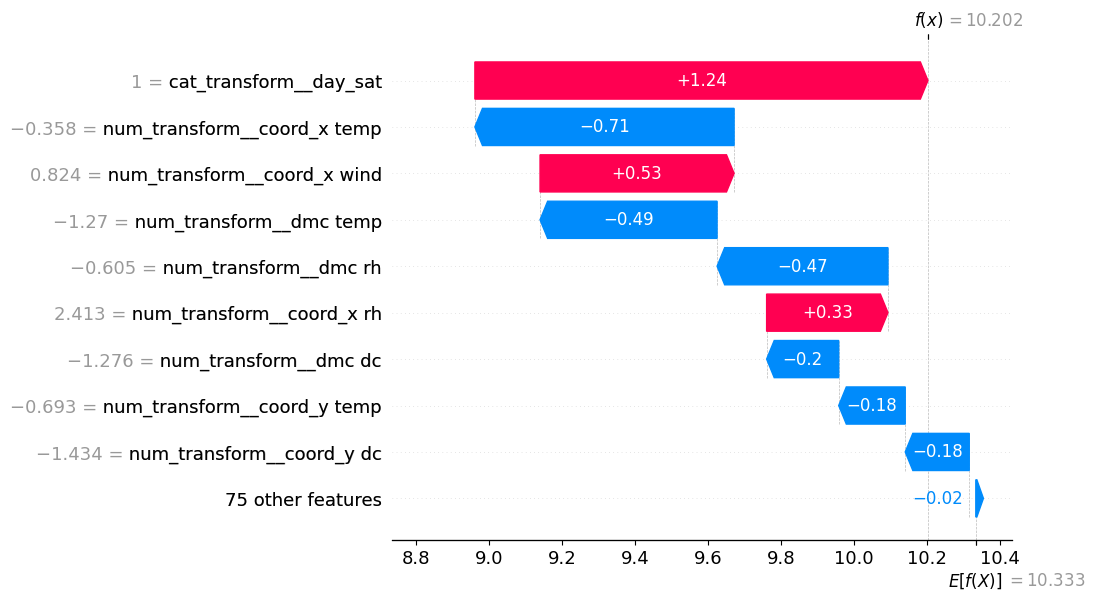

In [24]:
shap.plots.waterfall(shap_values[0], max_display=10)

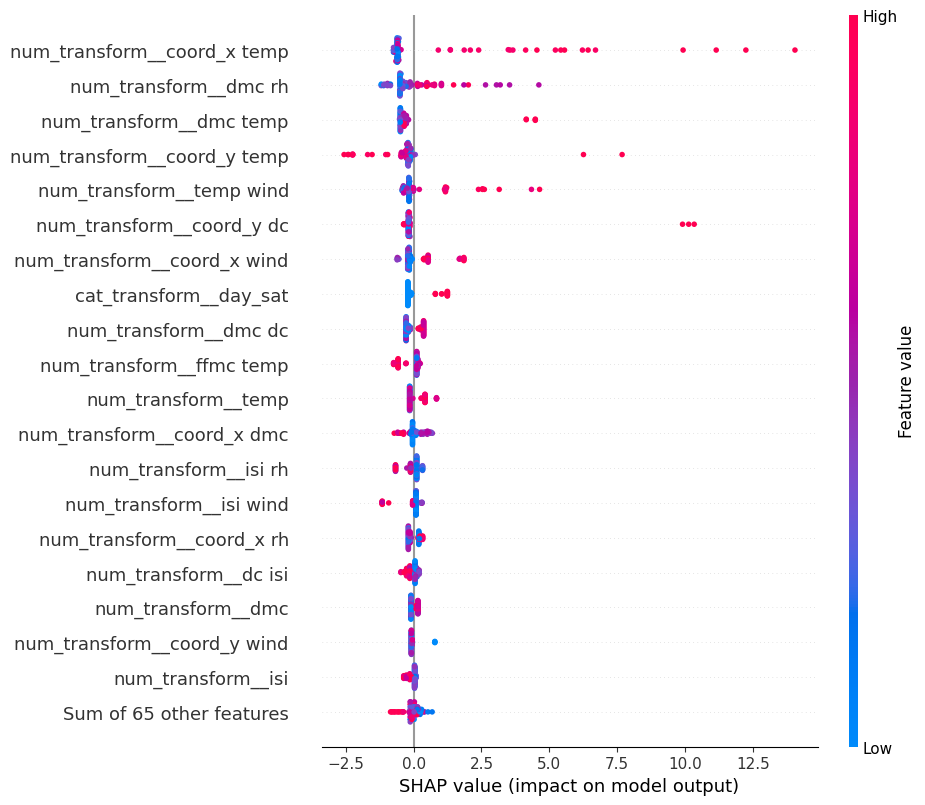

In [25]:
shap.plots.beeswarm(shap_values, max_display=20)

*(Answer here.)*

The local SHAP waterfall plot explains the prediction for one test observation. Features with positive SHAP values (like cat_transform__day_sat) pushed the predicted burned area higher, while features with negative SHAP values (like num_transform__coord_x temp) pushed the prediction lower.

The global SHAP beeswarm plot shows which features were most influential across the test set. The most important variables (like num_transform__coord_x temp, num_transform__dmc rh, num_transform__dmc temp, num_transform__coord_y temp, num_transform__temp wind, and num_transform__coord_y dc) appear at the top of the plot because they have the largest average absolute SHAP values.

Features with consistently low SHAP values (like num_transform__isi, num_transform_coord_y wind, or num_transform__dmc, num_transform__dc isi, num_transform___coord_x rh, and 65 other features) appear to contribute little to the model. These would be candidates for removal. To test whether removing them improves or hurts performance, I would retrain the same pipeline without those features and compare cross-validated RMSE and MAE against the original model.

## Criteria

The [rubric](./assignment_2_rubric_clean.xlsx) contains the criteria for assessment.

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/production/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [x] Created a branch with the correct naming convention.
- [x] Ensured that the repository is public.
- [x] Reviewed the PR description guidelines and adhered to them.
- [x] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at the `help` channel. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.

# Reference

Cortez,Paulo and Morais,Anbal. (2008). Forest Fires. UCI Machine Learning Repository. https://doi.org/10.24432/C5D88D.